# Redes Neuronales Convolucionales (CNNs)

Ya hemos trabajado con distintos tipos de redes neuronales: desde el clásico `Perceptrón Multicapa` hasta las `redes recurrentes` que usamos para predicción de series temporales. Ahora le toca el turno a una arquitectura especialmente diseñada para imágenes: las **Redes Neuronales Convolucionales**, o simplemente **CNNs**. En este notebook vamos a entender cómo funcionan y a construir una para clasificar flores.

## Introducción

Las CNNs tienen una historia larga: surgieron del estudio del córtex visual del cerebro humano y llevan siendo usadas para reconocimiento de imágenes desde los años 80. Sin embargo, fue en la última década cuando realmente despegaron gracias al aumento de potencia computacional y la disponibilidad de grandes cantidades de datos. Hoy en día, las encontramos en coches autónomos, sistemas de búsqueda de imágenes, clasificación de vídeo automática, e incluso en reconocimiento de voz. Lo interesante es que no solo funcionan con imágenes, sino con cualquier tipo de dato que tenga estructura espacial.

### El córtex visual

La inspiración biológica de las CNNs viene de cómo funciona nuestro propio sistema visual. Las neuronas del córtex visual no "ven" toda la imagen de golpe, sino que cada una reacciona solo a una pequeña región llamada **campo receptivo local**. Además, distintas neuronas del mismo nivel reaccionan a distintos patrones simples: unas detectan líneas horizontales, otras verticales. A medida que subimos de capa, las neuronas integran esa información y reaccionan a patrones más complejos.

![](https://mymlpics.s3.eu-de.cloud-object-storage.appdomain.cloud/visual_cortex.png)

Siguiendo esta misma lógica, Yann LeCunn diseñó la arquitectura **LeNet-5** en 1998, que fue usada por bancos para reconocer números manuscritos en cheques. Esa es la esencia de lo que vamos a replicar aquí, pero aplicado a clasificar flores.

## La Capa Convolucional

El componente central de una CNN es la **capa convolucional**. Su trabajo es recorrer la imagen con pequeños filtros (también llamados *kernels*) y calcular el producto escalar entre cada filtro y la región de la imagen que cubre en ese momento. Ese proceso se llama **convolución**, y el resultado es un nuevo mapa que resalta ciertos patrones de la imagen.

En el siguiente gif se puede ver cómo un filtro de 3×3 se desliza por una imagen de 5×5:

![](https://miro.medium.com/max/1052/1*GcI7G-JLAQiEoCON7xFbhg.gif)

Si la imagen tiene múltiples canales (como RGB), los filtros también. Y al aplicar más de un filtro, obtenemos varios mapas de salida, uno por filtro. Así es como la red extrae distintos tipos de información de la misma imagen:

![](https://cdn-media-1.freecodecamp.org/images/gb08-2i83P5wPzs3SL-vosNb6Iur5kb5ZH43)

In [7]:
import torch
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
device

'cuda'

## Preparación del Dataset: Balanceo con Data Augmentation

Antes de ponernos a entrenar, vale la pena revisar si las clases de nuestro dataset de flores están equilibradas. Si una clase tiene muchas más imágenes que otra, la red aprenderá a favorecerla y el modelo quedará sesgado. Para evitar eso, vamos a aplicar **data augmentation** a las clases con menos ejemplos hasta igualar los conteos.

In [9]:
import os
from collections import Counter

data_path = './flowers'
classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

class_counts = {}
print("Estado actual del dataset:")
print("-" * 50)
for class_name in classes:
    class_path = os.path.join(data_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
    class_counts[class_name] = num_images
    print(f'{class_name}: {num_images} imágenes')

max_count = max(class_counts.values())
print(f'\nClase con más imágenes: {max_count}')
print(f'\nClases desbalanceadas:')
for classe, count in class_counts.items():
    if count < max_count:
        print(f'  - {classe}: necesita {max_count - count} imágenes adicionales')

Estado actual del dataset:
--------------------------------------------------
daisy: 1052 imágenes
dandelion: 1052 imágenes
rose: 1052 imágenes
sunflower: 1052 imágenes
tulip: 1052 imágenes

Clase con más imágenes: 1052

Clases desbalanceadas:


In [10]:
import numpy as np
from PIL import Image, ImageEnhance, ImageOps
import random

def augment_image(img):
    """
    Aplica transformaciones aleatorias a una imagen
    """
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    
    transformations = [
        lambda x: x.transpose(Image.FLIP_LEFT_RIGHT),  
        lambda x: x.rotate(random.randint(-20, 20), fillcolor=(255, 255, 255)),  
        lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.7, 1.3)),  
        lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)),  
        lambda x: ImageEnhance.Color(x).enhance(random.uniform(0.7, 1.3)),  
        lambda x: ImageEnhance.Sharpness(x).enhance(random.uniform(0.5, 1.5)),  
    ]
    
    num_transforms = random.randint(2, 3)
    selected_transforms = random.sample(transformations, num_transforms)
    
    for transform in selected_transforms:
        img = transform(img)
    
    return img

print('Función de augmentation definida correctamente')

Función de augmentation definida correctamente


In [11]:
from tqdm import tqdm

def balance_dataset(data_path, classes, target_count=None):
    """
    Balancea el dataset aplicando data augmentation a las clases minoritarias
    
    Args:
        data_path: ruta al directorio del dataset
        classes: lista de nombres de clases
        target_count: número objetivo de imágenes por clase (si None, usa el máximo existente)
    """
    class_counts = {}
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        num_images = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = num_images
    
    if target_count is None:
        target_count = max(class_counts.values())
    
    print(f'Objetivo: {target_count} imágenes por clase\n')
    
    total_generated = 0
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        current_count = class_counts[class_name]
        needed = target_count - current_count
        
        if needed <= 0:
            print(f'✓ {class_name}: Ya balanceado ({current_count} imágenes)') 
            continue
        
        print(f' {class_name}: Generando {needed} imágenes adicionales...')
        
        existing_images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
        
        for i in tqdm(range(needed), desc=f'  Augmentando {class_name}'):
            source_img_name = random.choice(existing_images)
            source_img_path = os.path.join(class_path, source_img_name)
            
            img = Image.open(source_img_path).convert('RGB')
            augmented_img = augment_image(img)
            
            base_name = os.path.splitext(source_img_name)[0]
            new_name = f'{base_name}_aug_{i:04d}.jpg'
            new_path = os.path.join(class_path, new_name)
            
            augmented_img.save(new_path, quality=95)
        
        total_generated += needed
        print(f'  ✓ {class_name}: {current_count} → {target_count} imágenes\n')
    
    print(f'{"="*50}')
    print(f'¡Dataset balanceado correctamente!')
    print(f'Total de imágenes generadas: {total_generated}')
    print(f'{"="*50}')

# balance_dataset(data_path, classes)

In [12]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# data_path = './flowers'
# classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

def load_dataset(data_path, classes, max_images_per_class=None):
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_path, class_name)
        image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
        
        if max_images_per_class:
            image_files = image_files[:max_images_per_class]
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((150, 150))
                images.append(np.array(img))
                labels.append(class_idx)
            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
    
    return np.array(images), np.array(labels)

print('Cargando dataset completo...')
all_images, all_labels = load_dataset(data_path, classes)
print(f'Total de imagenes: {len(all_images)}')
print(f'Shape de imagenes: {all_images.shape}')

Cargando dataset completo...
Total de imagenes: 5260
Shape de imagenes: (5260, 150, 150, 3)


In [13]:
all_images[0].shape, all_labels[0], classes[all_labels[0]]

((150, 150, 3), np.int64(0), 'daisy')

In [14]:
from sklearn.model_selection import train_test_split

train_imgs, test_imgs, train_labels, test_labels = train_test_split(
    all_images, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

train_imgs.shape, test_imgs.shape

((4208, 150, 150, 3), (1052, 150, 150, 3))

Con el dataset cargado y dividido en entrenamiento y test, podemos visualizar alguna imagen para confirmar que todo está bien. Así nos aseguramos de que las etiquetas coincidan con las imágenes antes de seguir.

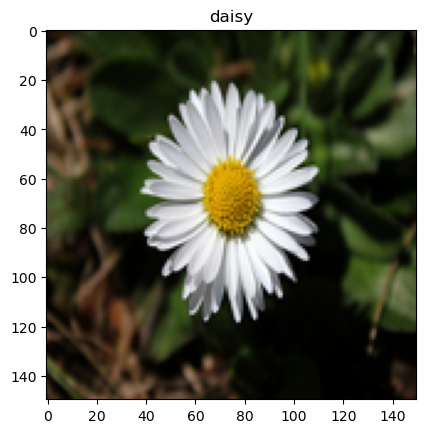

In [248]:
import random
import matplotlib.pyplot as plt

ix = random.randint(0, len(train_imgs))
img, label = train_imgs[ix], train_labels[ix]

plt.imshow(img)
plt.title(classes[label])
plt.show()

Para entender mejor qué hace una capa convolucional, vamos a aplicar un filtro manualmente antes de dejar que la red aprenda los suyos propios. El siguiente filtro de 3×3 tiene valores 1 en la primera fila, 0 en la central y -1 en la última: un clásico detector de **líneas horizontales**.

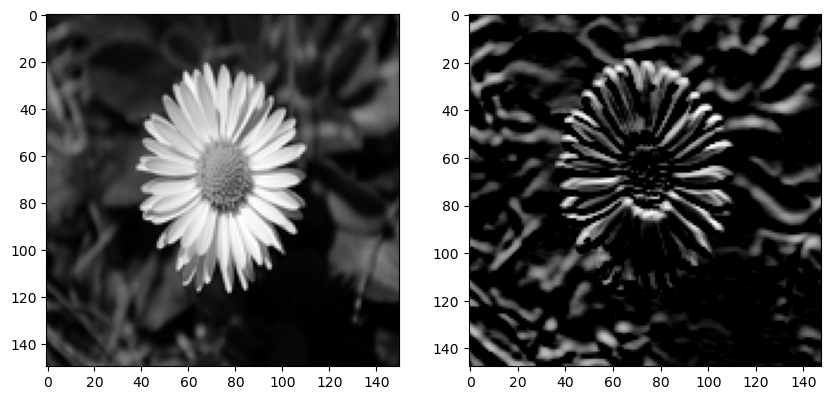

In [249]:
import numpy as np
import scipy.signal
from skimage import color
from skimage import exposure

img = color.rgb2gray(img)

kernel = np.array([[1,1,1],
                   [0,0,0],
                   [-1,-1,-1]])

edges = scipy.signal.convolve2d(img, kernel, 'valid')
edges = exposure.equalize_adapthist(edges/np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(img, cmap=plt.cm.gray)
ax2.imshow(edges, cmap=plt.cm.gray)
plt.show()

Si transponemos ese mismo filtro (intercambiando filas por columnas), ahora reacciona a **líneas verticales**. Es exactamente el mismo principio, solo que rotado 90 grados.

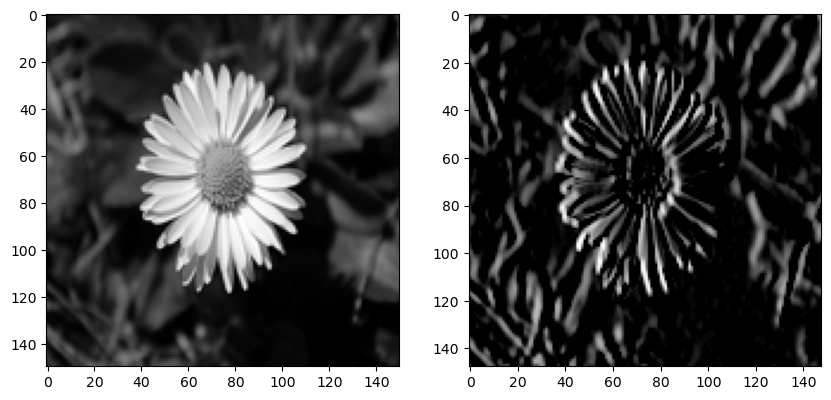

In [250]:
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

edges = scipy.signal.convolve2d(img, kernel, 'valid')
edges = exposure.equalize_adapthist(edges/np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(img, cmap=plt.cm.gray)
ax2.imshow(edges, cmap=plt.cm.gray)
plt.show()

Este otro filtro es más general: detecta bordes en cualquier dirección. Al combinar los cuatro vecinos inmediatos con signo negativo, resalta cualquier cambio brusco de intensidad en la imagen, independientemente de la orientación.

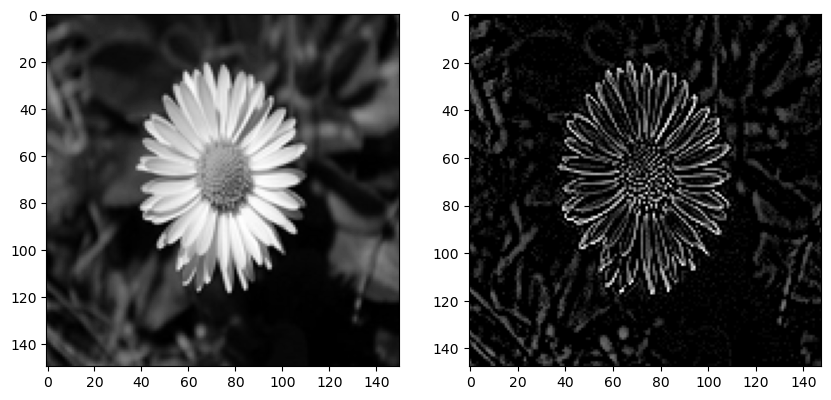

In [251]:
kernel = np.array([[0,-1,0],
                   [-1,4,-1],
                   [0,-1,0]])

edges = scipy.signal.convolve2d(img, kernel, 'valid')
edges = exposure.equalize_adapthist(edges/np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(img, cmap=plt.cm.gray)
ax2.imshow(edges, cmap=plt.cm.gray)
plt.show()

Como vemos, dependiendo del filtro que usemos podemos extraer distintas características de la imagen: bordes, texturas, líneas, etc. La pregunta clave es: **¿cómo elegimos los filtros correctos?** La respuesta es elegante — no los elegimos nosotros. Los valores de los filtros serán los **parámetros** de la red, y se aprenderán automáticamente durante el entrenamiento. La red descubrirá por sí sola qué patrones son más útiles para distinguir entre margaritas, girasoles o rosas.

### Implementación en Pytorch

En PyTorch, la capa convolucional está implementada en `torch.nn.Conv2d`. Le indicamos cuántos canales tiene la imagen de entrada, cuántos filtros queremos y el tamaño de esos filtros. Esta capa espera tensores con shape $(N, C_{in}, H, W)$: tamaño del batch, canales, alto y ancho. Primero tenemos que convertir nuestras imágenes al formato correcto antes de pasarlas.

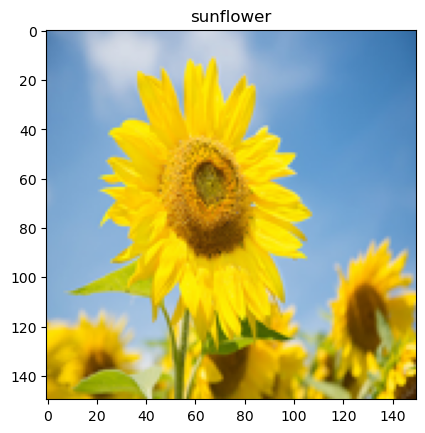

In [252]:
ix = random.randint(0, len(train_imgs))
img, label = train_imgs[ix], train_labels[ix]

plt.imshow(img)
plt.title(classes[label])
plt.show()

In [253]:
# convertir la imágen en tensor con dimensiones (N, C_in, H, W)

img_tensor = torch.from_numpy(img / 255.).unsqueeze(0)
img_tensor = img_tensor.permute(0, 3, 1, 2).float()

img_tensor.shape, img_tensor.dtype

(torch.Size([1, 3, 150, 150]), torch.float32)

In [254]:
# aplicamos 10 filtros de tamaño 3x3

conv = torch.nn.Conv2d(in_channels = 3, out_channels = 10, kernel_size = 3)

output = conv(img_tensor)

# dimensiones: (N, #filtros, H', W')
output.shape

torch.Size([1, 10, 148, 148])

Notar que las dimensiones espaciales de la salida cambian respecto a la entrada. Esto depende del tamaño del filtro, el *padding* y el *stride*. La fórmula general es:

$$ o = \left\lfloor \frac{n + 2p - m}{s} \right\rfloor + 1 $$

donde $o$ es la dimensión de salida, $n$ la de entrada, $m$ el tamaño del filtro, $p$ el padding (píxeles extra en los bordes) y $s$ el stride (cuántos píxeles salta el filtro en cada paso). Un caso habitual: con $p=1$, $s=1$ y filtro de 3×3, las dimensiones se conservan intactas.

In [255]:
conv = torch.nn.Conv2d(in_channels = 3, out_channels = 10, kernel_size = 3, padding = 0, stride = 2)

output = conv(img_tensor)

# dimensiones: (N, #filtros, H', W')
output.shape

torch.Size([1, 10, 74, 74])

In [256]:
img_tensor.shape

torch.Size([1, 3, 150, 150])

Usando $s = 2$ (stride de 2), el filtro salta de dos en dos, lo que reduce las dimensiones espaciales aproximadamente a la mitad. Es una forma barata de hacer submuestreo sin añadir capas extra.

In [257]:

conv = torch.nn.Conv2d(in_channels = 3, out_channels = 10, kernel_size = 3, padding = 1, stride = 2)

output = conv(img_tensor)

# dimensiones: (N, #filtros, H', W')
output.shape

torch.Size([1, 10, 75, 75])

In [258]:
conv1 = torch.nn.Conv2d(in_channels = 10, out_channels = 64, kernel_size = 3, padding = 0, stride = 1)

output2 = conv1(output)

# dimensiones: (N, #filtros, H', W')
output2.shape

torch.Size([1, 64, 73, 73])

En una CNN real apilamos varias capas convolucionales: la salida de una se convierte en la entrada de la siguiente. De esta manera, las primeras capas aprenden patrones simples (bordes, texturas), y las capas más profundas combinan esos patrones para reconocer formas más complejas. En el gif de abajo se puede ver este proceso jerárquico en acción.

![](https://thumbs.gfycat.com/AffectionateMemorableGreyhounddog-size_restricted.gif)

## Capas de *Pooling*

Además de las capas convolucionales, las CNNs suelen incluir **capas de pooling**. Su función es reducir la resolución de los mapas de características: toman una región y la reemplazan por un solo valor (el máximo, el promedio, etc.), sin parámetros que aprender.

![](https://miro.medium.com/max/1456/1*WvHC5bKyrHa7Wm3ca-pXtg.gif)

Esto tiene dos ventajas: reduce el costo computacional y hace que la red sea más robusta ante pequeñas variaciones de posición en la imagen. El pooling más común es el **MaxPool**, que se queda con el valor máximo de cada región.

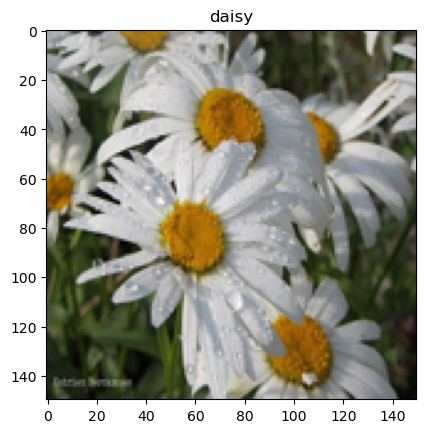

In [26]:
ix = random.randint(0, len(train_imgs))
img, label = train_imgs[ix], train_labels[ix]

plt.imshow(img)
plt.title(classes[label])
plt.show()

In [27]:
pool = torch.nn.MaxPool2d(3, padding=1, stride=2)

img_tensor = torch.from_numpy(img / 255.).unsqueeze(0).permute(0, 3, 1, 2).float()
output = pool(img_tensor)
output.shape

torch.Size([1, 3, 75, 75])

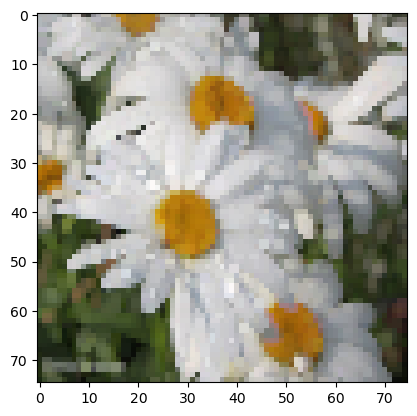

In [28]:
plt.imshow(output.squeeze(0).permute(1,2,0))
plt.show()

## Redes Convolucionales

Ahora que entendemos los bloques individuales, vamos a construir la CNN completa para clasificar nuestras 5 categorías de flores. Primero preparamos los tensores de entrenamiento y test, y organizamos los datos en `DataLoader` para iterar en batches durante el entrenamiento.

In [29]:
X_train = torch.tensor(train_imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
y_train = torch.tensor(train_labels, dtype=torch.long)

X_test = torch.tensor(test_imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
y_test = torch.tensor(test_labels, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

dataloader = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True),
    'test': torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True),
}

X_train.shape, X_test.shape

(torch.Size([4208, 3, 150, 150]), torch.Size([1052, 3, 150, 150]))

Diseñamos la arquitectura de la CNN. La idea es apilar bloques de convolución + BatchNorm + ReLU + MaxPool para extraer características progresivamente. Al final, aplanamos el mapa de salida y lo conectamos a una capa lineal que produce las 5 predicciones (una por tipo de flor).

In [30]:
def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.BatchNorm2d(c_out),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(pk, stride=ps)
    )

def block2(c_in, c_out):
    return torch.nn.Sequential(
        torch.nn.Linear(c_in, c_out),
        torch.nn.ReLU()
    )

class CNN(torch.nn.Module):
  def __init__(self, n_channels=3, n_outputs=5):
    super().__init__()
    self.conv1 = block(n_channels, 32)
    self.conv2 = block(32, 64)
    self.conv3 = block(64, 128)
    self.fc = torch.nn.Linear(128 * 3 * 3, n_outputs)

  def forward(self, x):
    print("Dimensiones:")
    print("Entrada: ", x.shape)
    x = self.conv1(x)
    print("conv1: ", x.shape)
    x = self.conv2(x)
    print("conv2: ", x.shape)
    x = self.conv3(x)
    print("conv3: ", x.shape)
    x = x.view(x.shape[0], -1)
    print("pre fc: ", x.shape)
    x = self.fc(x)
    print("Salida: ", x.shape)
    return x

In [31]:
model = CNN(n_channels=1, n_outputs=5)

output = model(torch.randn(128, 1, 28, 28))

Dimensiones:
Entrada:  torch.Size([128, 1, 28, 28])
conv1:  torch.Size([128, 32, 14, 14])
conv2:  torch.Size([128, 64, 7, 7])
conv3:  torch.Size([128, 128, 3, 3])
pre fc:  torch.Size([128, 1152])
Salida:  torch.Size([128, 5])


Al usar filtros de 3×3 con `padding=1` y `stride=1`, las dimensiones espaciales se mantienen constantes a lo largo de las capas convolucionales. La reducción de resolución queda a cargo exclusivamente de los MaxPool. Al llegar a la capa lineal, necesitamos aplanar el tensor: pasamos de $(N, C, H, W)$ a un vector de una sola dimensión para poder hacer la clasificación final.

In [263]:
class CNN(torch.nn.Module):
    def __init__(self, n_channels=3, n_outputs=len(classes)):
        super().__init__()
        self.conv1 = block(n_channels, 64)
        self.conv2 = block(64, 128)
        self.conv3 = block(128, 256)
        self.conv4 = block(256, 512)
        self.dropout = torch.nn.Dropout(0.5)
        self.fc = torch.nn.Linear(512 * 9 * 9, n_outputs)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.shape[0], -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

Con la arquitectura lista, entrenamos el modelo usando el bucle estándar de optimización con Adam y Cross Entropy Loss. El bucle itera por los batches de entrenamiento, calcula el gradiente y actualiza los pesos; luego evalúa en el set de test sin actualizar nada. Vamos a ver cómo evoluciona la precisión por épocas.

In [264]:
from tqdm import tqdm
import numpy as np

def fit(model, dataloader, epochs=35):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    for epoch in range(1, epochs+1):
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")
        bar = tqdm(dataloader['test'])
        val_loss, val_acc = [], []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {np.mean(val_loss):.5f} acc {np.mean(train_acc):.5f} val_acc {np.mean(val_acc):.5f}")

In [265]:
model = CNN(n_channels=3, n_outputs=len(classes))
fit(model, dataloader)

  0%|          | 0/66 [00:00<?, ?it/s]

val_loss 0.98989 val_acc 0.59861: 100%|██████████| 17/17 [00:01<00:00, 13.85it/s]


Epoch 1/35 loss 1.28564 val_loss 0.98989 acc 0.50939 val_acc 0.59861


val_loss 0.88048 val_acc 0.66649: 100%|██████████| 17/17 [00:01<00:00, 14.97it/s]


Epoch 2/35 loss 0.89319 val_loss 0.88048 acc 0.66162 val_acc 0.66649


...

Epoch 33/35 loss 0.02077 val_loss 0.66618 acc 0.99787 val_acc 0.79635


val_loss 0.91196 val_acc 0.76129: 100%|██████████| 17/17 [00:01<00:00, 14.72it/s]


Epoch 34/35 loss 0.02175 val_loss 0.91196 acc 0.99787 val_acc 0.76129


val_loss 0.91054 val_acc 0.76733: 100%|██████████| 17/17 [00:01<00:00, 14.89it/s]

Epoch 35/35 loss 0.02724 val_loss 0.91054 acc 0.99384 val_acc 0.76733


## Evaluación: Matriz de Confusión

Con el modelo entrenado, vamos a analizarlo más a fondo con una **matriz de confusión**. Esto nos dice exactamente qué flores identifica bien el modelo y con cuáles se confunde. Por ejemplo, podremos ver si mezcla margaritas con dientes de león, o si el girasol lo clasifica casi perfecto. Es una forma mucho más informativa que ver solo el accuracy global.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, dataloader, classes, device):
    """
    Genera predicciones y calcula métricas de evaluación
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader['test'], desc='Evaluando'):
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            preds = torch.argmax(y_hat, axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Número de predicciones'})
    plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
    plt.ylabel('Etiqueta Real', fontsize=12)
    plt.xlabel('Etiqueta Predicha', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print('\n' + '='*60)
    print('REPORTE DE CLASIFICACIÓN')
    print('='*60)
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))
    
    print('='*60)
    print('PRECISIÓN POR CLASE')
    print('='*60)
    for i, class_name in enumerate(classes):
        class_correct = cm[i, i]
        class_total = cm[i, :].sum()
        accuracy = (class_correct / class_total * 100) if class_total > 0 else 0
        print(f'{class_name:15s}: {accuracy:6.2f}% ({class_correct}/{class_total})')
    
    total_correct = np.trace(cm)
    total_samples = cm.sum()
    overall_accuracy = total_correct / total_samples * 100
    print('='*60)
    print(f'{"PRECISIÓN GENERAL":15s}: {overall_accuracy:6.2f}% ({total_correct}/{total_samples})')
    print('='*60)
    
    return cm, all_preds, all_labels

Evaluando: 100%|██████████| 17/17 [00:01<00:00, 14.85it/s]


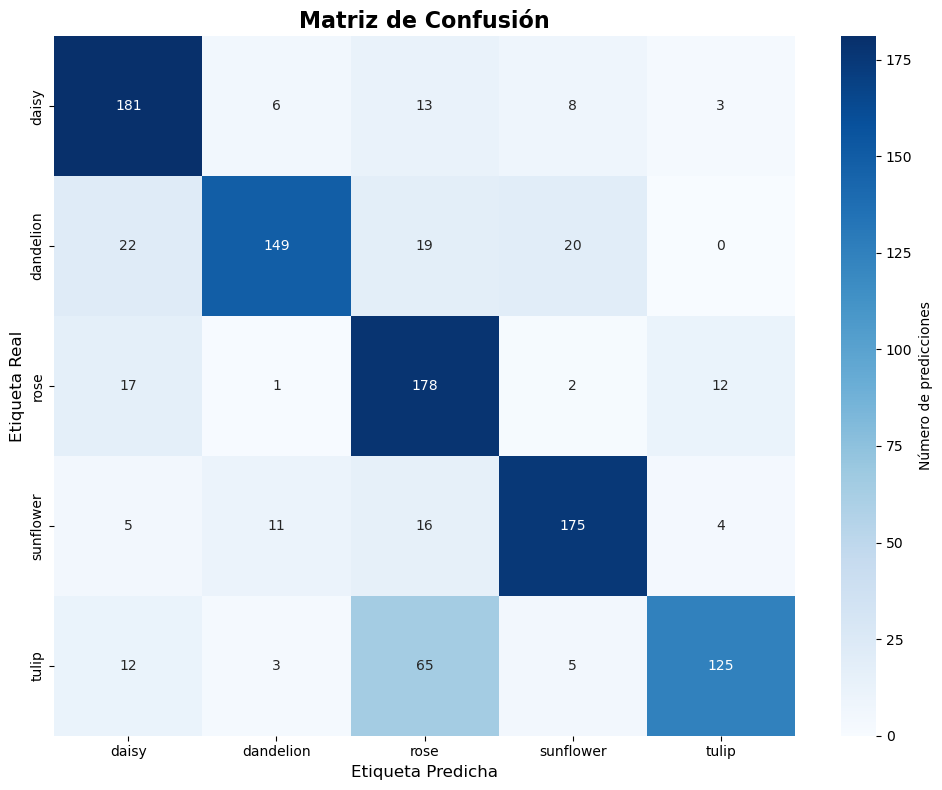


REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

       daisy     0.7637    0.8578    0.8080       211
   dandelion     0.8765    0.7095    0.7842       210
        rose     0.6117    0.8476    0.7106       210
   sunflower     0.8333    0.8294    0.8314       211
       tulip     0.8681    0.5952    0.7062       210

    accuracy                         0.7681      1052
   macro avg     0.7907    0.7679    0.7681      1052
weighted avg     0.7907    0.7681    0.7682      1052

PRECISIÓN POR CLASE
daisy          :  85.78% (181/211)
dandelion      :  70.95% (149/210)
rose           :  84.76% (178/210)
sunflower      :  82.94% (175/211)
tulip          :  59.52% (125/210)
PRECISIÓN GENERAL:  76.81% (808/1052)


In [262]:
cm, preds, labels = evaluate_model(model, dataloader, classes, device)